In [10]:
# import all the packages needed
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')


In [11]:
# 1. load in the dataset 
scorecard_raw = pd.read_csv(
    "college-scorecard-institution.csv",
    na_values=["PrivacySuppressed", "NULL"],
)


# 2. Filter to bachelor’s-degree institutions only
#    - PREDDEG: 3 = bachelor’s predominant degree
scorecard = scorecard_raw[scorecard_raw["PREDDEG"] == 3].copy()
print("After restricting to bachelor’s (PREDDEG == 3):", scorecard.shape)


# 3. Construct unified net price variable
#    - NPT4_PUB = net price for public schools
#    - NPT4_PRIV = net price for private schools
scorecard["net_price"] = scorecard["NPT4_PUB"].fillna(scorecard["NPT4_PRIV"])


# 4. Construct family_income confounder from income brackets
#
# We use:
#   NUM41_PUB/PRIV: # students, family income 0–30k
#   NUM42_PUB/PRIV: 30,001–48k
#   NUM43_PUB/PRIV: 48,001–75k
#   NUM44_PUB/PRIV: 75,001–110k
#   NUM45_PUB/PRIV: 110k+
#
# family_income_j = sum_b (n_jb * midpoint_b) / sum_b n_jb



# Bracket midpoints for NUM41-45 as weights
midpoints = [15000, 39000, 61500, 92500, 130000]

pub_cols  = ["NUM41_PUB", "NUM42_PUB", "NUM43_PUB", "NUM44_PUB", "NUM45_PUB"]
priv_cols = ["NUM41_PRIV", "NUM42_PRIV", "NUM43_PRIV", "NUM44_PRIV", "NUM45_PRIV"]

# Fill missing counts with 0 so sums work
pub_counts  = scorecard[pub_cols].fillna(0)
priv_counts = scorecard[priv_cols].fillna(0)

# Prepare an empty container for unified counts by bracket
counts = pd.DataFrame(
    0.0,
    index=scorecard.index,
    columns=["b1", "b2", "b3", "b4", "b5"]
)

is_pub  = scorecard["CONTROL"] == 1
is_priv = scorecard["CONTROL"].isin([2, 3])  # private nonprofit & for-profit

# Copy the right bracket counts into unified structure
counts.loc[is_pub, :]  = pub_counts.loc[is_pub].to_numpy()
counts.loc[is_priv, :] = priv_counts.loc[is_priv].to_numpy()

# Total students with income info
total_students = counts.sum(axis=1)

# Weighted average family income
weighted_sum = (counts * midpoints).sum(axis=1)
family_income = weighted_sum / total_students

# If no bracket info, set to NaN
family_income[total_students == 0] = pd.NA

scorecard["family_income"] = family_income


# 5. Construct standardized test index
#    Standardized test index combining SAT (verbal + math) and ACT when SAT is missing
sat_avg = scorecard[["SATVRMID", "SATMTMID"]].mean(axis=1)
sat_z = (sat_avg - sat_avg.mean(skipna=True)) / sat_avg.std(skipna=True)
act_z = (scorecard["ACTCMMID"] - scorecard["ACTCMMID"].mean(skipna=True)) / scorecard["ACTCMMID"].std(skipna=True)

scorecard["test_index"] = sat_z
scorecard["test_index"] = scorecard["test_index"].fillna(act_z)



# 6. Keep only columns we need for the analysis

keep_cols = [
    # IDs / basic info
    "UNITID", "INSTNM", "STABBR", "PREDDEG", "CONTROL", "UGDS",

    # Net price & family income
    "NPT4_PUB", "NPT4_PRIV", "net_price", "family_income",

    # Income bracket counts (for reproducibility / robustness checks)
    "NUM41_PUB", "NUM42_PUB", "NUM43_PUB", "NUM44_PUB", "NUM45_PUB",
    "NUM41_PRIV", "NUM42_PRIV", "NUM43_PRIV", "NUM44_PRIV", "NUM45_PRIV",

    # Outcomes
    "MD_EARN_WNE_P10",              # earnings
    "GRAD_DEBT_MDN_SUPP",          # median debt
    "GRAD_DEBT_MDN10YR_SUPP",      # 10-year monthly payment
    "RPY_3YR_RT_SUPP",             # repayment rate

    # Low-income access
    "PCTPELL", "PCTFLOAN",

    # Student quality -- used to construct test_index
    "SATVRMID", "SATMTMID", "ACTCMMID", "test_index"
]

scorecard = scorecard[keep_cols].copy()


# Readable column names
rename_map = {
    "UNITID": "institution_id",
    "INSTNM": "institution_name",
    "STABBR": "state",
    "PREDDEG": "predominant_degree",
    "CONTROL": "control_type",
    "UGDS": "undergrad_enrollment",
    "NPT4_PUB": "net_price_public",
    "NPT4_PRIV": "net_price_private",
    "MD_EARN_WNE_P10": "median_earnings_10yr",
    "GRAD_DEBT_MDN_SUPP": "median_debt",
    "GRAD_DEBT_MDN10YR_SUPP": "median_debt_10yr_payment",
    "RPY_3YR_RT_SUPP": "repayment_rate_3yr",
    "PCTPELL": "pell_grant_share",
    "PCTFLOAN": "federal_loan_share",
    "SATVRMID": "sat_verbal_midpoint",
    "SATMTMID": "sat_math_midpoint",
    "ACTCMMID": "act_composite_midpoint",
}
scorecard = scorecard.rename(columns=rename_map)

control_map = {1: "Public", 2: "Private nonprofit", 3: "Private for-profit"}
scorecard["control_label"] = scorecard["control_type"].map(control_map)

# Basic sanity filters: non-negative values for selected columns
non_negative_cols = [
    "net_price",
    "family_income",
    "median_earnings_10yr",
    "median_debt",
    "median_debt_10yr_payment",
    "repayment_rate_3yr",
    "undergrad_enrollment",
    "pell_grant_share",
    "federal_loan_share",
]

sanity_mask = pd.Series(True, index=scorecard.index)
for col in non_negative_cols:
    sanity_mask &= scorecard[col].isna() | (scorecard[col] >= 0)
scorecard = scorecard.loc[sanity_mask].copy()

print("After column selection & sanity filters:", scorecard.shape)

scorecard.head()


/var/folders/0n/wt5mbzb12nqc2r3ld1dxgss00000gn/T/ipykernel_17135/3748688617.py:2: DtypeWarning: Columns (9,1729,1743,1909,1910,1911,1912,1913,2251,2252,2254,2256,2258) have mixed types. Specify dtype option on import or set low_memory=False.
  scorecard_raw = pd.read_csv(


After restricting to bachelor’s (PREDDEG == 3): (2004, 3214)
After column selection & sanity filters: (2003, 31)


,institution_id,institution_name,state,predominant_degree,control_type,undergrad_enrollment,net_price_public,net_price_private,net_price,family_income,NUM41_PUB,NUM42_PUB,NUM43_PUB,NUM44_PUB,NUM45_PUB,NUM41_PRIV,NUM42_PRIV,NUM43_PRIV,NUM44_PRIV,NUM45_PRIV,median_earnings_10yr,median_debt,median_debt_10yr_payment,repayment_rate_3yr,pell_grant_share,federal_loan_share,sat_verbal_midpoint,sat_math_midpoint,act_composite_midpoint,test_index,control_label
0,100654,Alabama A & M University,AL,3,1,5098.0,13057.0,NaN,13057.0,33573.820396,381.0,141.0,76.0,40.0,19.0,NaN,NaN,NaN,NaN,NaN,39059.0,31000.0,328.651592,0.253155,0.6853,0.6552,475.0,460.0,18.0,-1.612496,Public
1,100663,University of Alabama at Birmingham,AL,3,1,13284.0,16585.0,NaN,16585.0,63021.367521,322.0,195.0,161.0,126.0,249.0,NaN,NaN,NaN,NaN,NaN,50907.0,22300.0,236.417113,0.513963,0.3253,0.4401,637.0,644.0,27.0,0.896500,Public
2,100690,Amridge University,AL,3,2,251.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37730.0,32189.0,341.256971,0.230769,0.7852,0.8423,NaN,NaN,NaN,NaN,Private nonprofit
3,100706,University of Alabama in Huntsville,AL,3,1,7358.0,17250.0,NaN,17250.0,66507.766990,141.0,72.0,99.0,84.0,119.0,NaN,NaN,NaN,NaN,NaN,56901.0,20705.0,219.507459,0.548509,0.2377,0.3578,640.0,655.0,28.0,0.998020,Public
4,100724,Alabama State University,AL,3,1,3495.0,13593.0,NaN,13593.0,27260.765550,284.0,87.0,28.0,12.0,7.0,NaN,NaN,NaN,NaN,NaN,34018.0,31000.0,328.651592,0.218587,0.7205,0.7637,488.0,457.0,18.0,-1.539981,Public


In [12]:
scorecard.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2003 entries, 0 to 6039
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   institution_id            2003 non-null   int64  
 1   institution_name          2003 non-null   object 
 2   state                     2003 non-null   object 
 3   predominant_degree        2003 non-null   int64  
 4   control_type              2003 non-null   int64  
 5   undergrad_enrollment      2003 non-null   float64
 6   net_price_public          551 non-null    float64
 7   net_price_private         1276 non-null   float64
 8   net_price                 1827 non-null   float64
 9   family_income             1830 non-null   float64
 10  NUM41_PUB                 552 non-null    float64
 11  NUM42_PUB                 552 non-null    float64
 12  NUM43_PUB                 552 non-null    float64
 13  NUM44_PUB                 552 non-null    float64
 14  NUM45_PUB    

In [13]:
# Keep rows with non-missing net price and earnings
q1_data = scorecard.dropna(
    subset=["net_price", "median_earnings_10yr", "control_type"]
).copy()

sector_labels = {1: "Public", 2: "Private nonprofit", 3: "Private for-profit"}
q1_data["sector"] = q1_data["control_type"].map(sector_labels)

# Summary stats by sector
summary_by_sector = (
    q1_data
    .groupby("sector")[["net_price", "median_earnings_10yr"]]
    .describe()
)
summary_by_sector


net_price                                               \
                       count          mean          std     min       25%   
sector                                                                      
Private for-profit     118.0  25615.822034  8002.579648  4845.0  19320.25   
Private nonprofit     1044.0  22696.704023  7875.427301  1392.0  18034.75   
Public                 546.0  13915.434066  4471.987682  1936.0  11327.50   

                                               median_earnings_10yr  \
                        50%       75%      max                count   
sector                                                                
Private for-profit  24577.0  30343.75  50183.0                118.0   
Private nonprofit   22316.5  26832.50  50747.0               1044.0   
Public              14053.0  16857.25  27926.0                546.0   

                                                                            \
                            mean           std      min       25%      50%   
sector                                                                       
Private for-profit  48083.576271  19765.684853  19736.0  35237.00  42990.0   
Private nonprofit   53068.445402  16550.227056  17347.0  42960.00  51154.0   
Public              51889.032967  11736.677589  21688.0  44415.75  50447.0   

                                        
                         75%       max  
sector                                  
Private for-profit  49338.25   99806.0  
Private nonprofit   60147.00  129137.0  
Public              57893.00   99713.0

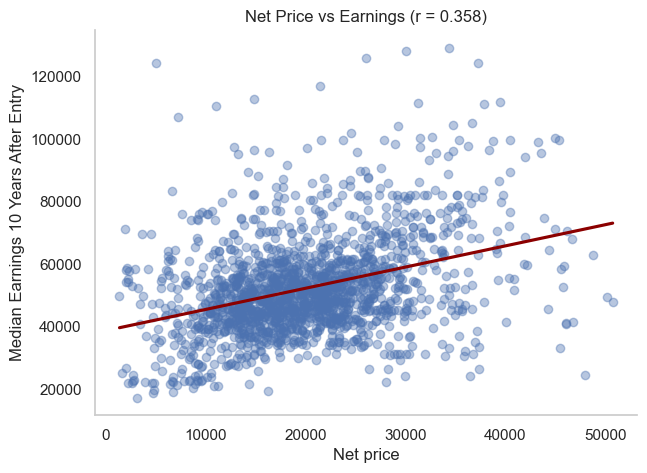

In [14]:
# Q1.1: Relationship between net price and median earnings (overall)
q1 = scorecard[["net_price", "median_earnings_10yr"]].dropna()
# print("Correlation (net price vs earnings):", q1.corr().iloc[0, 1].round(3))
plt.figure(figsize=(7, 5))
sns.regplot(data=q1, x="net_price", y="median_earnings_10yr", scatter_kws={"alpha": 0.4}, line_kws={"color": "darkred"}, ci=None)
r = q1.corr().iloc[0,1]
plt.title(f"Net Price vs Earnings (r = {r:.3f})")
plt.xlabel("Net price")
plt.ylabel("Median Earnings 10 Years After Entry")
sns.despine()
plt.grid(False)
plt.show()



<Figure size 500x800 with 0 Axes>

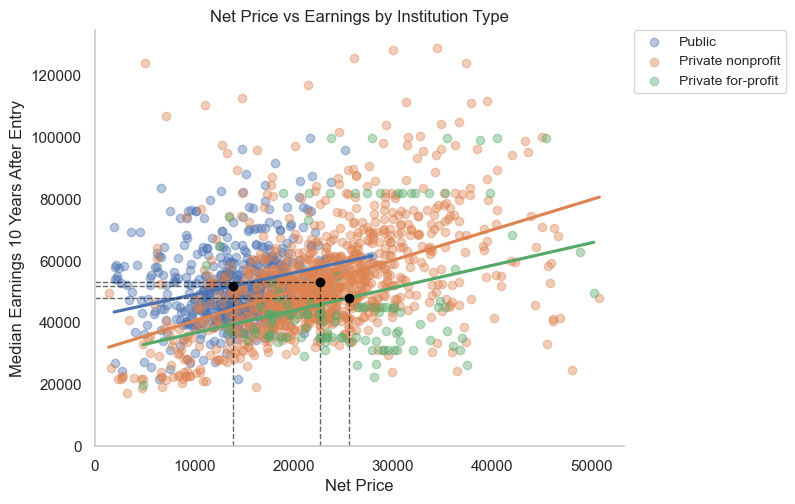

In [15]:
q1_type = scorecard[["net_price", "median_earnings_10yr", "control_label"]].dropna()
plt.figure(figsize=(5, 8))
g = sns.lmplot(
    data=q1_type,
    x="net_price",
    y="median_earnings_10yr",
    hue="control_label",
    scatter_kws={"alpha": 0.4},
    height=5,
    aspect=1.3,
    ci=None, 
    legend=False    # turn off default legend to customize later
)

ax = g.ax

# 1. set axes to start at (0,0)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

xmin = 0
ymin = 0
ax.set_xlim(left=xmin, right=xmax)
ax.set_ylim(bottom=ymin, top=ymax)

# 2. plot mean points and dashed guides to axes
group_means = q1_type.groupby("control_label")[["net_price", "median_earnings_10yr"]].mean()

for label, row in group_means.iterrows():
    x_pt = row["net_price"]
    y_pt = row["median_earnings_10yr"]

    # plot mean point
    ax.plot(x_pt, y_pt, marker="o", color="black", zorder=5)

    # plot dashed line to axes to x axis
    ax.vlines(
        x=x_pt,
        ymin=ymin,
        ymax=y_pt,
        colors="black",
        linestyles="dashed",
        linewidth=1,
        alpha=0.6,
    )

    # plot dashed line to axes to x axis
    ax.hlines(
        y=y_pt,
        xmin=xmin,
        xmax=x_pt,
        colors="black",
        linestyles="dashed",
        linewidth=1,
        alpha=0.6,
    )

# adjust the legend
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.,
    fontsize="small"
)


ax.set_xlabel("Net Price")
ax.set_ylabel("Median Earnings 10 Years After Entry")
ax.set_title("Net Price vs Earnings by Institution Type")
sns.despine()

plt.grid(False)
plt.show()


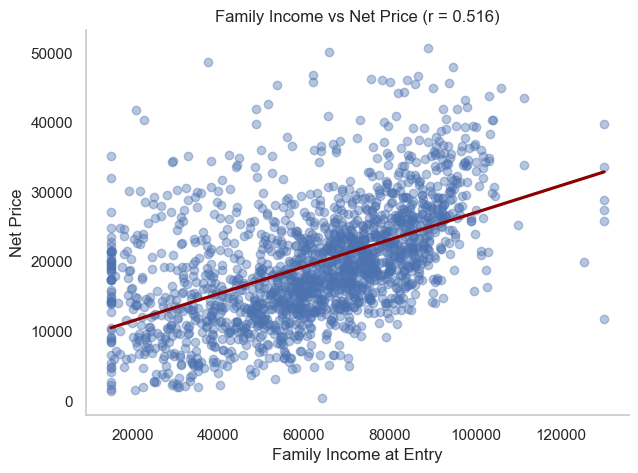

In [16]:
# Q2.1: Family income vs net price
q2_price = scorecard[["family_income", "net_price"]].dropna()
# print("Correlation (family income vs net price):", q2_price.corr().iloc[0, 1].round(3))
plt.figure(figsize=(7, 5))
sns.regplot(data=q2_price, x="family_income", y="net_price", scatter_kws={"alpha": 0.4}, line_kws={"color": "darkred"},  ci=None)
plt.xlabel("Family Income at Entry")
plt.ylabel("Net Price")

r = q2_price.corr().iloc[0, 1]
plt.title(f"Family Income vs Net Price (r = {r:.3f})")
plt.grid(False)
sns.despine()
plt.show()


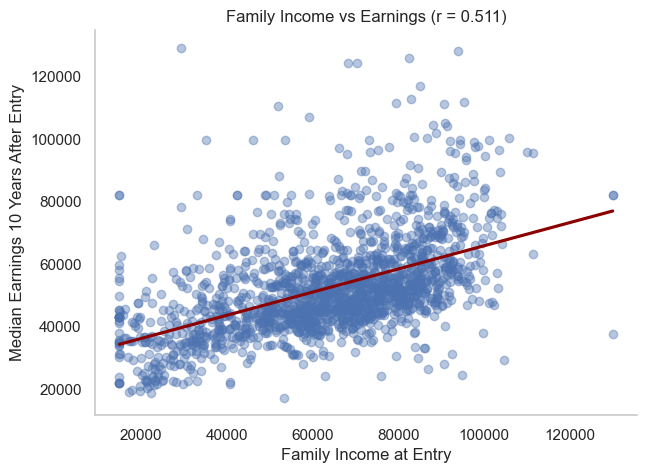

In [17]:
# Q2.2: Family income vs earnings
q2_earn = scorecard[["family_income", "median_earnings_10yr"]].dropna()
# print("Correlation (family income vs earnings):", q2_earn.corr().iloc[0, 1].round(3))
plt.figure(figsize=(7, 5))
sns.regplot(data=q2_earn, x="family_income", y="median_earnings_10yr", scatter_kws={"alpha": 0.4}, line_kws={"color": "darkred"}, ci=None)
plt.xlabel("Family Income at Entry")
plt.ylabel("Median Earnings 10 Years After Entry")

r = q2_earn.corr().iloc[0, 1]
plt.title(f"Family Income vs Earnings (r = {r:.3f})")

plt.grid(False)
sns.despine()
plt.show()


In [18]:
# Q2.3: OLS — earnings on net price, controlling for family income and test scores
ols_data = scorecard[["median_earnings_10yr", "net_price", "family_income", "test_index", "control_label", "undergrad_enrollment"]].dropna()

earn_simple = ols("median_earnings_10yr ~ net_price", data=ols_data).fit(cov_type="HC3")
earn_full = ols(
    "median_earnings_10yr ~ net_price + family_income + test_index + C(control_label) + np.log1p(undergrad_enrollment)",
    data=ols_data,
).fit(cov_type="HC3")

earn_coef_order = [
    "net_price",
    "family_income",
    "test_index",
    "C(control_label)[T.Private nonprofit]",
    "C(control_label)[T.Private for-profit]",
]
earn_coef_labels = {
    "net_price": "Net price",
    "family_income": "Family income",
    "test_index": "Test index",
    "C(control_label)[T.Private nonprofit]": "Private nonprofit",
    "C(control_label)[T.Private for-profit]": "For-profit",
}

earnings_table = (
    pd.DataFrame(
        {
            "Simple": earn_simple.params.reindex(earn_coef_order),
            "Full": earn_full.params.reindex(earn_coef_order),
        }
    ).rename(index=earn_coef_labels)
)
earnings_table


,Simple,Full
Net price,0.845144,0.319137
Family income,NaN,0.019832
Test index,NaN,9263.892768
Private nonprofit,NaN,-3235.805550
For-profit,NaN,NaN


In [19]:
# Q3.1: Schools with highest debt burden by sector
cols = ["institution_name", "state", "control_label", "median_debt", "median_debt_10yr_payment", "net_price", "family_income"]
top_debt = scorecard[cols].dropna(subset=["median_debt"]).sort_values("median_debt", ascending=False)
top_debt_by_sector = (
    top_debt.groupby("control_label")
    .head(10)
    [["institution_name", "state", "control_label", "median_debt", "net_price", "family_income"]]
)
top_debt_by_sector.head(10)


,institution_name,state,control_label,median_debt,net_price,family_income
4590,Eagle Gate College-Layton,UT,Private for-profit,43021.0,24833.0,17181.818182
3296,Eagle Gate College-Murray,UT,Private for-profit,43021.0,24749.0,18096.774194
2596,The North Coast College,OH,Private for-profit,42785.0,23124.0,53750.000000
3729,Platt College-Aurora,CO,Private for-profit,42125.0,41975.0,48833.333333
1038,Martin University,IN,Private nonprofit,42002.0,15271.0,19000.000000
3919,Provo College,UT,Private for-profit,41733.0,25531.0,23645.161290
4985,Strayer University-Arkansas,AR,Private for-profit,40621.0,21340.0,15000.000000
5035,Strayer University-Global Region,DC,Private for-profit,40621.0,22776.0,15000.000000
4989,Strayer University-Texas,TX,Private for-profit,40621.0,17681.0,19000.000000
4988,Strayer University-South Carolina,SC,Private for-profit,40621.0,18461.0,15000.000000


In [20]:
# Q3.2: Predictors of debt and repayment (OLS)
from IPython.display import display

reg_data = scorecard[["median_debt", "median_debt_10yr_payment", "repayment_rate_3yr", "net_price", "family_income", "test_index", "control_label", "undergrad_enrollment"]].dropna()

coef_order = [
    "net_price",
    "family_income",
    "test_index",
    "C(control_label)[T.Private nonprofit]",
    "C(control_label)[T.Private for-profit]",
]
coef_labels = {
    "net_price": "Net price",
    "family_income": "Family income",
    "test_index": "Test index",
    "C(control_label)[T.Private nonprofit]": "Private nonprofit",
    "C(control_label)[T.Private for-profit]": "For-profit",
}

# Debt outcome
_debt_simple = ols("median_debt ~ net_price", data=reg_data).fit(cov_type="HC3")
_debt_full = ols(
    "median_debt ~ net_price + family_income + test_index + C(control_label) + np.log1p(undergrad_enrollment)",
    data=reg_data,
).fit(cov_type="HC3")

debt_table = (
    pd.DataFrame(
        {
            "Simple": _debt_simple.params.reindex(coef_order),
            "Full": _debt_full.params.reindex(coef_order),
        }
    ).rename(index=coef_labels)
)

# Repayment outcome
_repay_simple = ols("repayment_rate_3yr ~ net_price", data=reg_data).fit(cov_type="HC3")
_repay_full = ols(
    "repayment_rate_3yr ~ net_price + family_income + test_index + C(control_label) + np.log1p(undergrad_enrollment)",
    data=reg_data,
).fit(cov_type="HC3")

repay_table = (
    pd.DataFrame(
        {
            "Simple": _repay_simple.params.reindex(coef_order),
            "Full": _repay_full.params.reindex(coef_order),
        }
    ).rename(index=coef_labels)
)

display(debt_table)
display(repay_table)


,Simple,Full
Net price,0.132733,0.134532
Family income,NaN,0.042269
Test index,NaN,-1929.344423
Private nonprofit,NaN,-1735.474750
For-profit,NaN,NaN


,Simple,Full
Net price,0.000009,7.101939e-08
Family income,NaN,3.542063e-06
Test index,NaN,8.699753e-02
Private nonprofit,NaN,1.882885e-02
For-profit,NaN,NaN


In [21]:
# Q4.1: Low-income access with good outcomes
pell_75 = scorecard["pell_grant_share"].quantile(0.75)
family_25 = scorecard["family_income"].quantile(0.25)
candidates = scorecard[(scorecard["pell_grant_share"] >= pell_75) | (scorecard["family_income"] <= family_25)]
cols = ["institution_name", "state", "control_label", "family_income", "pell_grant_share", "net_price", "median_earnings_10yr", "repayment_rate_3yr"]
good_outcomes = (
    candidates[cols]
    .dropna(subset=["median_earnings_10yr", "repayment_rate_3yr"])
    .sort_values(["median_earnings_10yr", "repayment_rate_3yr"], ascending=False)
    .head(10)
)
good_outcomes


,institution_name,state,control_label,family_income,pell_grant_share,net_price,median_earnings_10yr,repayment_rate_3yr
1789,University of Health Sciences and Pharmacy in ...,MO,Private nonprofit,29244.680851,0.3474,34371.0,129137.0,0.933673
4462,West Coast University-Los Angeles,CA,Private for-profit,53666.666667,0.4911,45392.0,99806.0,0.693750
4972,West Coast University-Ontario,CA,Private for-profit,73090.909091,0.5430,40424.0,99806.0,0.693750
5253,West Coast University-Dallas,TX,Private for-profit,46100.000000,0.6091,23761.0,99806.0,0.693750
5481,West Coast University-Miami,FL,Private for-profit,35093.750000,0.6491,27859.0,99806.0,0.693750
993,Oak Point University,IL,Private nonprofit,NaN,0.5022,NaN,84630.0,0.797945
4784,Chamberlain University-Ohio,OH,Private for-profit,15000.000000,0.5215,18944.0,82055.0,0.595370
4785,Chamberlain University-Arizona,AZ,Private for-profit,33000.000000,0.4248,35174.0,82055.0,0.595370
4903,Chamberlain University-Florida,FL,Private for-profit,68833.333333,0.5507,30489.0,82055.0,0.595370
5068,Chamberlain University-Virginia,VA,Private for-profit,130000.000000,0.4711,33644.0,82055.0,0.595370


In [22]:
# Q4.2: Schools over-performing on earnings relative to student background (value-added residuals)
va_data = scorecard[["median_earnings_10yr", "family_income", "test_index", "control_label", "undergrad_enrollment"]].dropna()
va_model = ols(
    "median_earnings_10yr ~ family_income + test_index + C(control_label) + np.log1p(undergrad_enrollment)",
    data=va_data,
).fit(cov_type="HC3")

resid = va_model.resid
scorecard["value_added"] = (resid - resid.mean()) / resid.std()
va_data = va_data.assign(value_added=scorecard.loc[va_data.index, "value_added"])
va_ranked = va_data.join(scorecard[["institution_name", "state"]]).sort_values("value_added", ascending=False).head(10)
va_ranked[["institution_name", "state", "control_label", "median_earnings_10yr", "family_income", "test_index", "value_added"]]


,institution_name,state,control_label,median_earnings_10yr,family_income,test_index,value_added
1789,University of Health Sciences and Pharmacy in ...,MO,Private nonprofit,129137.0,29244.680851,0.127848,8.037810
2015,Albany College of Pharmacy and Health Sciences,NY,Private nonprofit,125798.0,82550.000000,0.889248,6.401937
1448,MCPHS University,MA,Private nonprofit,124126.0,68342.369478,0.599191,6.333712
301,Harvey Mudd College,CA,Private nonprofit,128215.0,93853.932584,2.629592,4.805110
2846,University of the Sciences,PA,Private nonprofit,104361.0,88210.820896,0.417905,4.476997
1397,Bentley University,MA,Private nonprofit,111896.0,95428.723404,1.230065,4.231496
1392,Babson College,MA,Private nonprofit,111604.0,79387.295082,1.795677,3.835519
4416,Franklin W Olin College of Engineering,MA,Private nonprofit,116968.0,85120.000000,2.738363,3.741767
2249,SUNY Maritime College,NY,Public,87534.0,91944.785276,0.265625,3.210279
1533,Kettering University,MI,Private nonprofit,94491.0,100199.669967,0.599191,3.162996


In [23]:
# Q5.1: Best for keeping costs low (net price)
rank_cost = scorecard[["institution_name", "state", "control_label", "net_price", "median_earnings_10yr", "repayment_rate_3yr"]].dropna(subset=["net_price"]).sort_values("net_price").head(10)
rank_cost


,institution_name,state,control_label,net_price,median_earnings_10yr,repayment_rate_3yr
4673,Bais Medrash Toras Chesed,NJ,Private nonprofit,469.0,NaN,NaN
669,Luther Rice College & Seminary,GA,Private nonprofit,1392.0,49700.0,0.259804
2124,Kehilath Yakov Rabbinical Seminary,NY,Private nonprofit,1596.0,25314.0,NaN
5942,Oak Valley College,CA,Private nonprofit,1684.0,NaN,NaN
2069,CUNY Bernard M Baruch College,NY,Public,1936.0,71078.0,0.651617
206,California State University-Los Angeles,CA,Public,2037.0,54219.0,0.582207
2074,CUNY City College,NY,Public,2061.0,58052.0,0.525468
3603,Colegio Universitario de San Juan,PR,Public,2068.0,26829.0,NaN
2077,CUNY Hunter College,NY,Public,2124.0,58822.0,0.567591
198,California State University-San Bernardino,CA,Public,2232.0,55258.0,0.521855


In [24]:
# Q5.2: Best for maximizing earnings
rank_earnings = scorecard[["institution_name", "state", "control_label", "net_price", "median_earnings_10yr", "repayment_rate_3yr"]].dropna(subset=["median_earnings_10yr"]).sort_values("median_earnings_10yr", ascending=False).head(10)
rank_earnings


,institution_name,state,control_label,net_price,median_earnings_10yr,repayment_rate_3yr
411,Samuel Merritt University,CA,Private nonprofit,NaN,129442.0,0.916923
1789,University of Health Sciences and Pharmacy in ...,MO,Private nonprofit,34371.0,129137.0,0.933673
301,Harvey Mudd College,CA,Private nonprofit,30026.0,128215.0,NaN
2015,Albany College of Pharmacy and Health Sciences,NY,Private nonprofit,26073.0,125798.0,0.868078
1450,Massachusetts Institute of Technology,MA,Private nonprofit,5084.0,124213.0,0.918228
1448,MCPHS University,MA,Private nonprofit,37288.0,124126.0,0.826957
4416,Franklin W Olin College of Engineering,MA,Private nonprofit,21474.0,116968.0,NaN
2842,University of Pennsylvania,PA,Private nonprofit,14851.0,112761.0,0.844214
2247,SUNY Downstate Health Sciences University,NY,Public,NaN,112739.0,0.861702
1397,Bentley University,MA,Private nonprofit,39437.0,111896.0,0.913806


In [25]:
# Q5.3: Debt-averse ranking (low payments, acceptable earnings)
earn_median = scorecard["median_earnings_10yr"].median(skipna=True)
debt_averse = scorecard.dropna(subset=["median_debt_10yr_payment", "median_earnings_10yr"])
debt_averse = debt_averse[debt_averse["median_earnings_10yr"] >= earn_median]
debt_averse = debt_averse.sort_values("median_debt_10yr_payment").head(10)
debt_averse[["institution_name", "state", "control_label", "median_debt_10yr_payment", "median_earnings_10yr", "net_price"]]


,institution_name,state,control_label,median_debt_10yr_payment,median_earnings_10yr,net_price
2265,United States Merchant Marine Academy,NY,Public,93.644500,83499.0,6627.0
3287,Brigham Young University-Hawaii,HI,Private nonprofit,99.793466,50616.0,14904.0
1492,Wellesley College,MA,Private nonprofit,106.016643,75784.0,21561.0
1357,Johns Hopkins University,MD,Private nonprofit,108.667059,89551.0,14254.0
2084,CUNY Queens College,NY,Public,109.175939,58348.0,2933.0
1957,Princeton University,NJ,Private nonprofit,109.409175,110433.0,11080.0
2081,CUNY Lehman College,NY,Public,116.088224,52882.0,2615.0
2072,CUNY Brooklyn College,NY,Public,116.618307,57665.0,2393.0
2077,CUNY Hunter College,NY,Public,116.618307,58822.0,2124.0
2078,CUNY John Jay College of Criminal Justice,NY,Public,116.618307,54207.0,2254.0


In [26]:
# Q5.4: Mobility-oriented ranking (low cost, decent earnings, good repayment)
mob = scorecard[["institution_name", "state", "control_label", "net_price", "family_income", "median_earnings_10yr", "repayment_rate_3yr"]].dropna()
mob = mob.assign(
    cost_rank=mob["net_price"].rank(pct=True),
    earnings_rank=mob["median_earnings_10yr"].rank(pct=True),
    repayment_rank=mob["repayment_rate_3yr"].rank(pct=True),
    income_rank=mob["family_income"].rank(pct=True),
)
# Higher score = better: low net price and family income (reverse), high earnings and repayment
mob["mobility_score"] = (1 - mob["cost_rank"]) + (1 - mob["income_rank"]) + mob["earnings_rank"] + mob["repayment_rank"]
mobility_ranking = mob.sort_values("mobility_score", ascending=False).head(10)
mobility_ranking[["institution_name", "state", "control_label", "net_price", "family_income", "median_earnings_10yr", "repayment_rate_3yr", "mobility_score"]]


,institution_name,state,control_label,net_price,family_income,median_earnings_10yr,repayment_rate_3yr,mobility_score
1957,Princeton University,NJ,Private nonprofit,11080.0,51911.885246,110433.0,0.863946,3.593241
3656,Stanford University,CA,Private nonprofit,7200.0,59171.284635,106987.0,0.899200,3.572118
396,Pomona College,CA,Private nonprofit,9170.0,54752.577320,74305.0,0.851064,3.510260
211,University of California-Irvine,CA,Public,9691.0,46988.126160,76593.0,0.775523,3.502112
4303,University of Connecticut-Waterbury Campus,CT,Public,7599.0,50243.137255,76076.0,0.779809,3.497888
4305,University of Connecticut-Stamford,CT,Public,10225.0,53460.000000,76076.0,0.779809,3.419433
5149,University of Connecticut-Hartford Campus,CT,Public,9370.0,54578.239609,76076.0,0.779809,3.418829
2069,CUNY Bernard M Baruch College,NY,Public,1936.0,30776.360544,71078.0,0.651617,3.409173
3902,University of Washington-Tacoma Campus,WA,Public,8541.0,56461.538462,74063.0,0.790376,3.406156
1450,Massachusetts Institute of Technology,MA,Private nonprofit,5084.0,70468.013468,124213.0,0.918228,3.399517
